In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

uploaded = files.upload()
df = pd.read_csv("cafe_sales_cleaned_final.csv")
df.head()

Saving cafe_sales_cleaned_final.csv to cafe_sales_cleaned_final (1).csv


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-Store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-Store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-Store,2023-06-11


In [4]:
df.describe()          # statistik kolom numerik: mean, min, max, dll
df.describe(include='object')   # ringkasan kolom kategori: nilai unik, paling sering muncul

,Transaction ID,Item,Payment Method,Location,Transaction Date
count,9035,9035,9035,9035,9035
unique,9035,8,3,2,365
top,TXN_6170729,Coffee,Digital Wallet,Takeaway,2023-07-24
freq,1,1239,4944,6315,39


In [9]:
top_by_frequency = df['Item'].value_counts().head(10)
print(top_by_frequency)

Item
Coffee      1239
Salad       1212
Cookie      1144
Tea         1135
Juice       1120
Cake        1077
Sandwich    1066
Smoothie    1042
Name: count, dtype: int64


/tmp/ipykernel_3190/2969994749.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_by_frequency.values, y=top_by_frequency.index, palette="viridis")


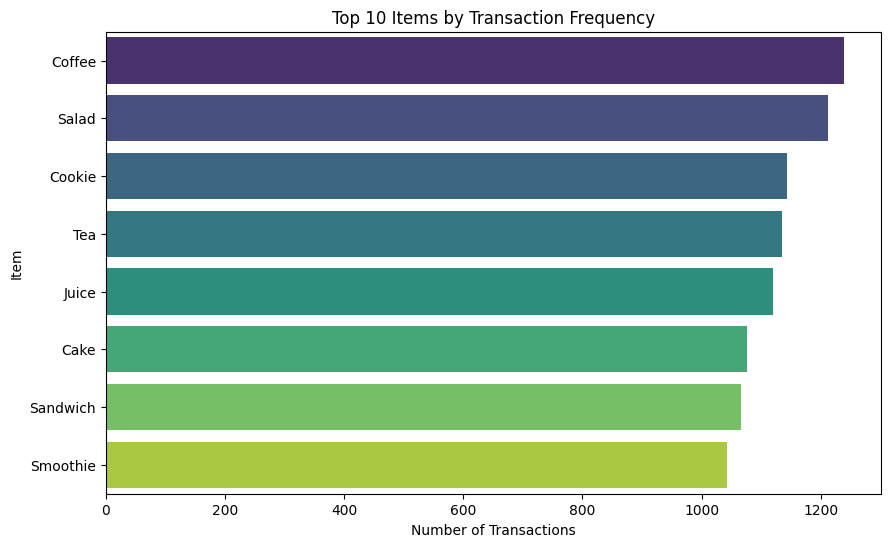

In [10]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_by_frequency.values, y=top_by_frequency.index, palette="viridis")
plt.title("Top 10 Items by Transaction Frequency")
plt.xlabel("Number of Transactions")
plt.ylabel("Item")
plt.show()

In [11]:
top_by_quantity = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_by_quantity)

Item
Coffee      3759.0
Salad       3638.0
Tea         3424.0
Cookie      3416.0
Juice       3339.0
Cake        3269.0
Sandwich    3249.0
Smoothie    3184.0
Name: Quantity, dtype: float64


/tmp/ipykernel_3190/3128529947.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_by_quantity.values, y=top_by_quantity.index, palette="mako")


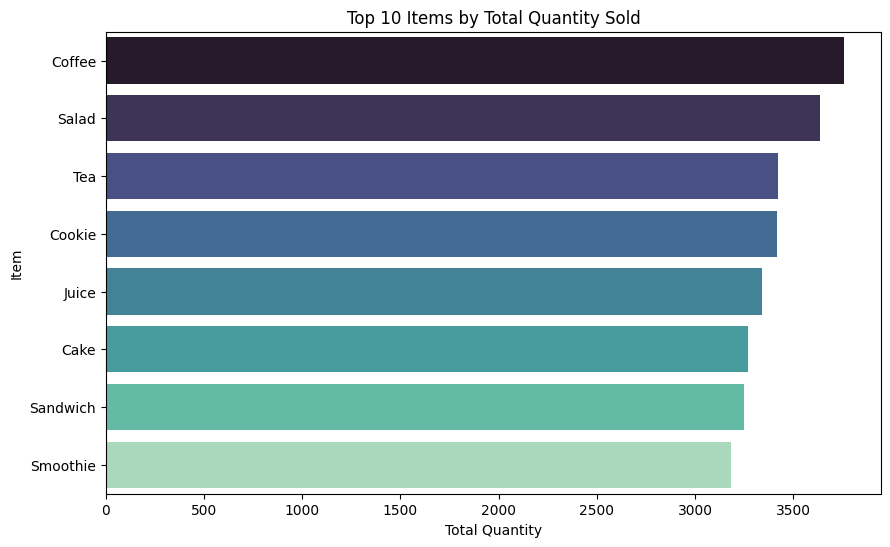

In [12]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_by_quantity.values, y=top_by_quantity.index, palette="mako")
plt.title("Top 10 Items by Total Quantity Sold")
plt.xlabel("Total Quantity")
plt.ylabel("Item")
plt.show()

In [13]:
top_by_revenue = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False).head(10)
print(top_by_revenue)

Item
Salad       18190.0
Sandwich    12996.0
Smoothie    12736.0
Juice       10017.0
Cake         9807.0
Coffee       7518.0
Tea          5136.0
Cookie       3416.0
Name: Total Spent, dtype: float64


/tmp/ipykernel_3190/2434635729.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_by_revenue.values, y=top_by_revenue.index, palette="rocket")


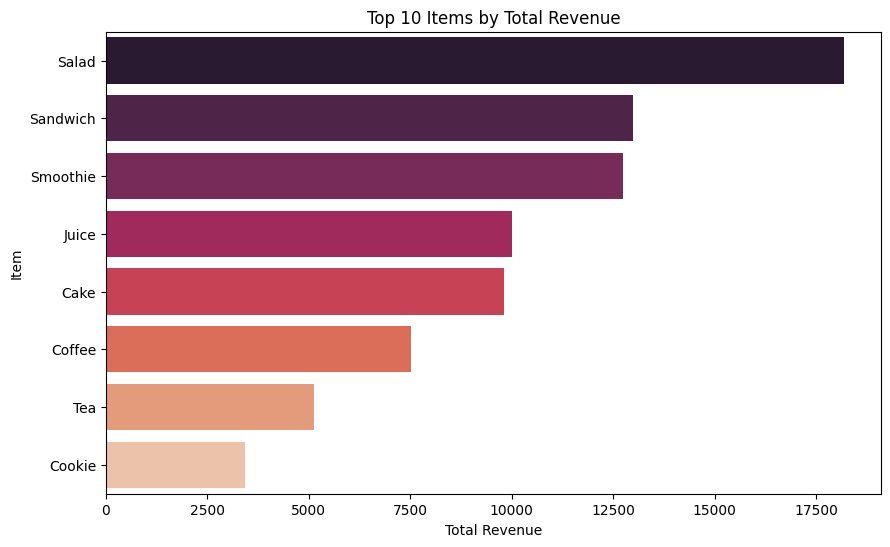

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_by_revenue.values, y=top_by_revenue.index, palette="rocket")
plt.title("Top 10 Items by Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Item")
plt.show()

In [15]:
payment_counts = df['Payment Method'].value_counts()
print(payment_counts)

Payment Method
Digital Wallet    4944
Credit Card       2049
Cash              2042
Name: count, dtype: int64


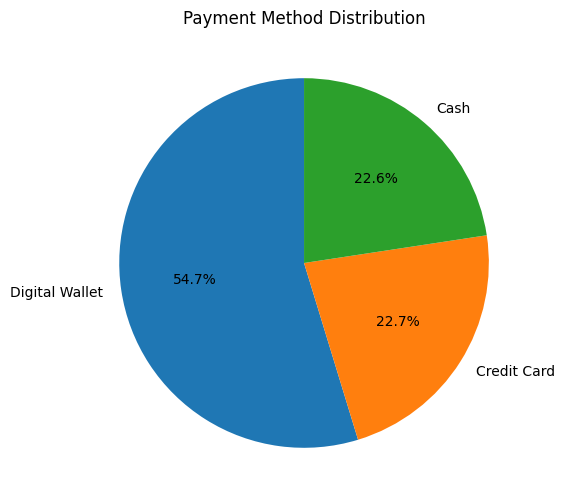

In [16]:
plt.figure(figsize=(6,6))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Payment Method Distribution")
plt.show()

In [17]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

# Total penjualan per bulan
monthly_sales = df.groupby(df['Transaction Date'].dt.to_period('M'))['Total Spent'].sum()
print(monthly_sales)

Transaction Date
2023-01    6883.0
2023-02    6160.0
2023-03    6882.5
2023-04    6732.0
2023-05    6490.5
2023-06    6871.0
2023-07    6558.5
2023-08    6546.5
2023-09    6408.0
2023-10    7021.0
2023-11    6640.0
2023-12    6623.0
Freq: M, Name: Total Spent, dtype: float64


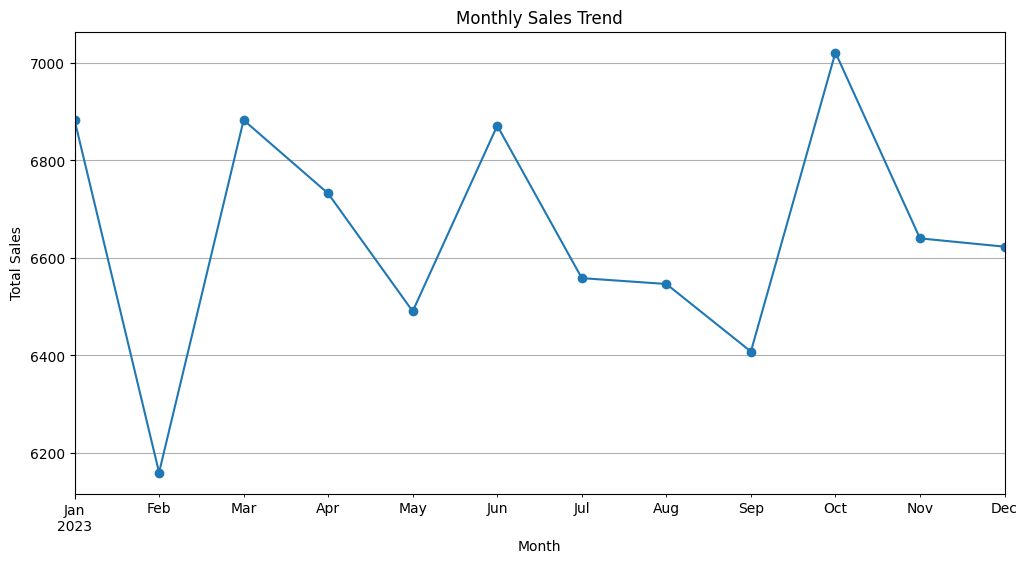

In [18]:
plt.figure(figsize=(12,6))
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

In [19]:
df['Day of Week'] = df['Transaction Date'].dt.day_name()
day_sales = df.groupby('Day of Week')['Total Spent'].sum()

# Urutkan berdasarkan urutan hari yang benar (bukan alfabet)
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_sales = day_sales.reindex(day_order)

print(day_sales)

Day of Week
Monday       11347.5
Tuesday      11348.5
Wednesday    10790.5
Thursday     11701.0
Friday       11651.5
Saturday     11302.5
Sunday       11674.5
Name: Total Spent, dtype: float64


/tmp/ipykernel_3190/357241999.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_sales.index, y=day_sales.values, palette="coolwarm")


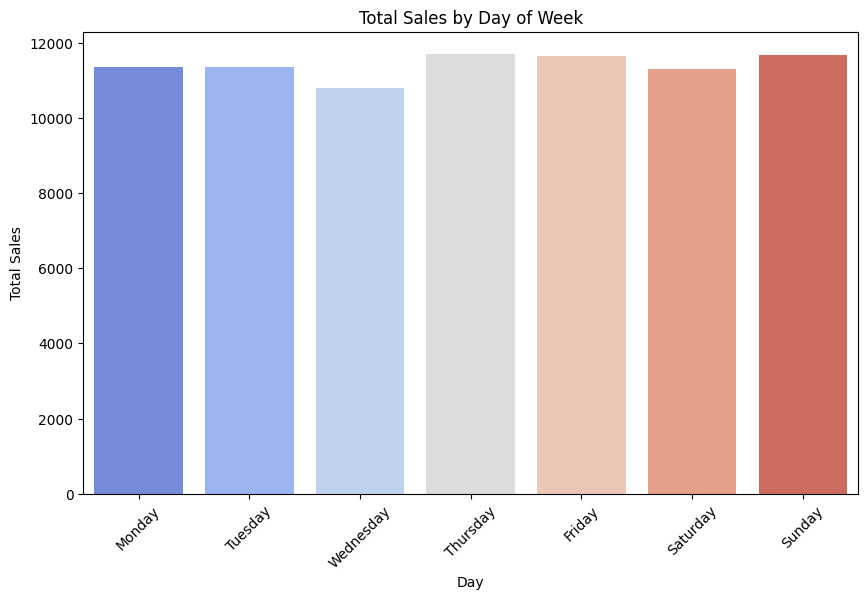

In [20]:
plt.figure(figsize=(10,6))
sns.barplot(x=day_sales.index, y=day_sales.values, palette="coolwarm")
plt.title("Total Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

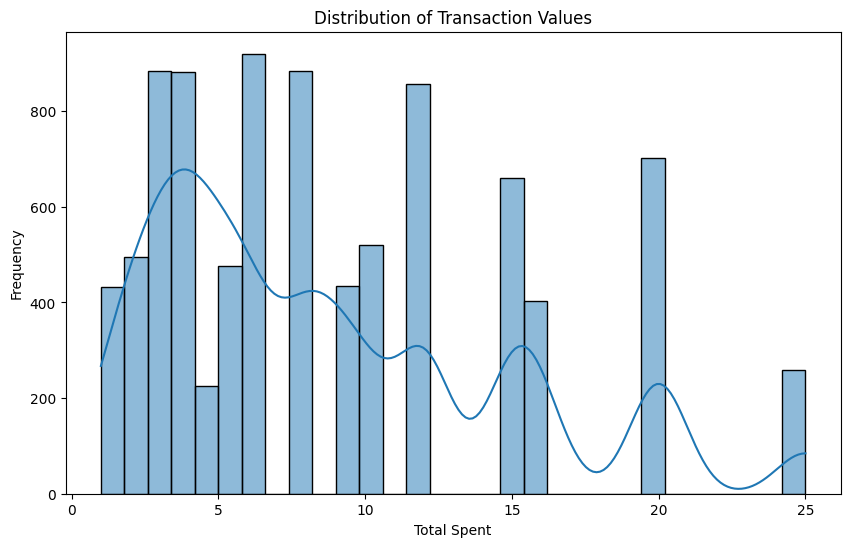

In [21]:
plt.figure(figsize=(10,6))
sns.histplot(df['Total Spent'], bins=30, kde=True)
plt.title("Distribution of Transaction Values")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")
plt.show()

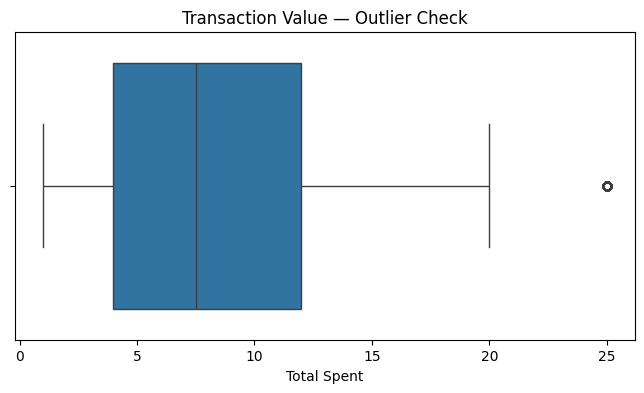

In [22]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Total Spent'])
plt.title("Transaction Value — Outlier Check")
plt.show()

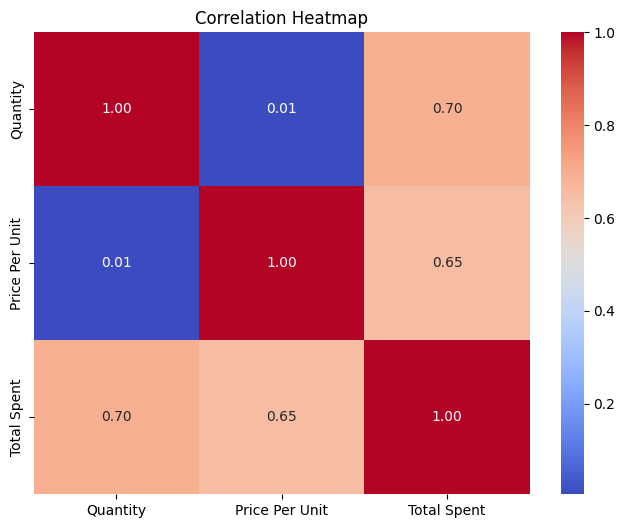

In [23]:
numeric_cols = df.select_dtypes(include='number')
correlation = numeric_cols.corr()

plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
